# Import  packges required for nlp processing and analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from rich.pretty import pprint

import spacy


### Data insights

In [2]:
plt.rcParams["figure.figsize"] = (12, 8)
default_color = "#00bfbf"

In [3]:
data = pd.read_csv(r'datasets\email_spam_dataset.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   email_text  320 non-null    str  
 1   label       320 non-null    str  
dtypes: str(2)
memory usage: 5.1 KB


In [4]:
data.head()

,email_text,label
0,Here is the project update you asked for.,ham
1,Limited offer!!! Buy now and get 50% discount.,spam
2,Win cash prizes instantly by replying to this ...,spam
3,Urgent! Your account has been suspended. Verif...,spam
4,"Hi, please find the meeting agenda attached.",ham


Text(0.5, 1.0, 'Count Email Classification (Spam vs Ham)')

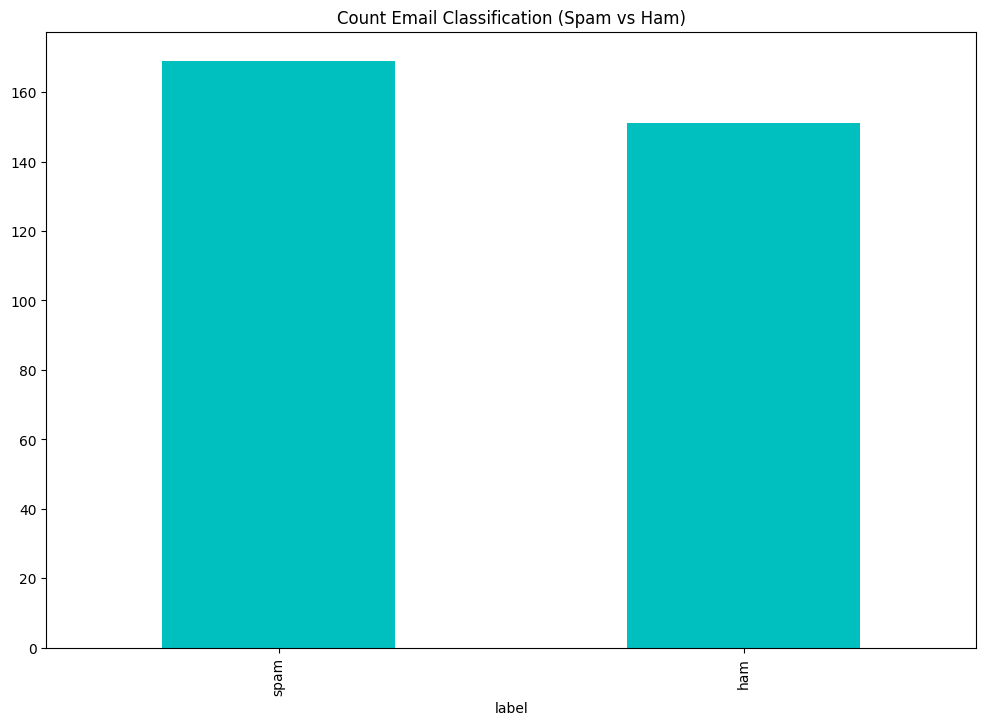

In [5]:
# comparing the number of spam to the number ham in the dataset
data["label"].value_counts().plot(kind="bar", color="#00bfbf")
plt.title("Count Email Classification (Spam vs Ham)")

In [6]:
pprint(data["label"][data["label"] == "spam"].value_counts())
pprint(data["label"][data["label"] == "ham"].value_counts())

label
spam    169
Name: count, dtype: int64

label
ham    151
Name: count, dtype: int64

# Text Tagging
Anaylsis text to find part of search and named entity that appear most in the dataset which will help the model understand the structure and meaning of sentences by identifying the roles of word and thier relationships

In [7]:
spam = data[data["label"] == "spam"]
ham = data[data["label"] == "ham"]

In [8]:
spam

,email_text,label
1,Limited offer!!! Buy now and get 50% discount.,spam
2,Win cash prizes instantly by replying to this ...,spam
3,Urgent! Your account has been suspended. Verif...,spam
8,You are selected for a free gift card. Act fast.,spam
10,Win cash prizes instantly by replying to this ...,spam
...,...,...
314,Win cash prizes instantly by replying to this ...,spam
316,You are selected for a free gift card. Act fast.,spam
317,Win cash prizes instantly by replying to this ...,spam
318,Limited offer!!! Buy now and get 50% discount.,spam


In [9]:
ham

,email_text,label
0,Here is the project update you asked for.,ham
4,"Hi, please find the meeting agenda attached.",ham
5,Here is the project update you asked for.,ham
6,Can we reschedule our meeting to tomorrow?,ham
7,Hope you are doing well. Let's catch up soon.,ham
...,...,...
306,Can we reschedule our meeting to tomorrow?,ham
307,Hope you are doing well. Let's catch up soon.,ham
309,"Hi, please find the meeting agenda attached.",ham
312,Here is the project update you asked for.,ham


### Pos Tagging

In [13]:
nlp = spacy.load("en_core_web_sm")
spam_doc = list(nlp.pipe(spam["email_text"]))
ham_doc = list(nlp.pipe(ham["email_text"]))

In [14]:
pprint(spam_doc)
pprint(ham_doc)

[
│   Limited offer!!! Buy now and get 50% discount.,
│   Win cash prizes instantly by replying to this email.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   You are selected for a free gift card. Act fast.,
│   Win cash prizes instantly by replying to this email.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Win cash prizes instantly by replying to this email.,
│   Win cash prizes instantly by replying to this email.,
│   You are selected for a free gift card. Act fast.,
│   Win cash prizes instantly by replying to this email.,
│   You are selected for a free gift card. Act fast.,
│   Win cash prizes instantly by replying to this email.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Limited offer!!! Buy now and get 50% discount.,
│   You are selected for a free gift card. Act fast.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   You are selected for a free gift card. Act fast.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Win cash prizes instantly by replying to this email.,
│   You are selected for a free gift card. Act fast.,
│   You are selected for a free gift card. Act fast.,
│   Win cash prizes instantly by replying to this email.,
│   Win cash prizes instantly by replying to this email.,
│   Win cash prizes instantly by replying to this email.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Win cash prizes instantly by replying to this email.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Win cash prizes instantly by replying to this email.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Win cash prizes instantly by replying to this email.,
│   Win cash prizes instantly by replying to this email.,
│   Win cash prizes instantly by replying to this email.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   You are selected for a free gift card. Act fast.,
│   Win cash prizes instantly by replying to this email.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Win cash prizes instantly by replying to this email.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Win cash prizes instantly by replying to this email.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Win cash prizes instantly by replying to this email.,
│   You are selected for a free gift card. Act fast.,
│   Congratulations! You have won a free lottery. Click here to claim now.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Limited offer!!! Buy now and get 50% discount.,
│   You are selected for a free gift card. Act fast.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   You are selected for a free gift card. Act fast.,
│   Limited offer!!! Buy now and get 50% discount.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   Limited offer!!! Buy now and get 50% discount.,
│   You are selected for a free gift card. Act fast.,
│   Congratulations! You have won a free lottery. Click he

[
│   Here is the project update you asked for.,
│   Hi, please find the meeting agenda attached.,
│   Here is the project update you asked for.,
│   Can we reschedule our meeting to tomorrow?,
│   Hope you are doing well. Let's catch up soon.,
│   Thank you for your support. Let me know if you need anything.,
│   Thank you for your support. Let me know if you need anything.,
│   Can we reschedule our meeting to tomorrow?,
│   Thank you for your support. Let me know if you need anything.,
│   Hi, please find the meeting agenda attached.,
│   Thank you for your support. Let me know if you need anything.,
│   Can we reschedule our meeting to tomorrow?,
│   Thank you for your support. Let me know if you need anything.,
│   Can we reschedule our meeting to tomorrow?,
│   Can we reschedule our meeting to tomorrow?,
│   Thank you for your support. Let me know if you need anything.,
│   Thank you for your support. Let me know if you need anything.,
│   Thank you for your support. Let me know if you need anything.,
│   Can we reschedule our meeting to tomorrow?,
│   Here is the project update you asked for.,
│   Can we reschedule our meeting to tomorrow?,
│   Here is the project update you asked for.,
│   Hope you are doing well. Let's catch up soon.,
│   Hi, please find the meeting agenda attached.,
│   Here is the project update you asked for.,
│   Hi, please find the meeting agenda attached.,
│   Thank you for your support. Let me know if you need anything.,
│   Hi, please find the meeting agenda attached.,
│   Here is the project update you asked for.,
│   Hi, please find the meeting agenda attached.,
│   Thank you for your support. Let me know if you need anything.,
│   Here is the project update you asked for.,
│   Can we reschedule our meeting to tomorrow?,
│   Can we reschedule our meeting to tomorrow?,
│   Can we reschedule our meeting to tomorrow?,
│   Hope you are doing well. Let's catch up soon.,
│   Thank you for your support. Let me know if you need anything.,
│   Hi, please find the meeting agenda attached.,
│   Hope you are doing well. Let's catch up soon.,
│   Can we reschedule our meeting to tomorrow?,
│   Here is the project update you asked for.,
│   Thank you for your support. Let me know if you need anything.,
│   Hope you are doing well. Let's catch up soon.,
│   Can we reschedule our meeting to tomorrow?,
│   Hi, please find the meeting agenda attached.,
│   Thank you for your support. Let me know if you need anything.,
│   Here is the project update you asked for.,
│   Thank you for your support. Let me know if you need anything.,
│   Hi, please find the meeting agenda attached.,
│   Hope you are doing well. Let's catch up soon.,
│   Here is the project update you asked for.,
│   Can we reschedule our meeting to tomorrow?,
│   Hope you are doing well. Let's catch up soon.,
│   Thank you for your support. Let me know if you need anything.,
│   Hi, please find the meeting agenda attached.,
│   Can we reschedule our meeting to tomorrow?,
│   Hope you are doing well. Let's catch up soon.,
│   Can we reschedule our meeting to tomorrow?,
│   Here is the project update you asked for.,
│   Thank you for your support. Let me know if you need anything.,
│   Hi, please find the meeting agenda attached.,
│   Hi, please find the meeting agenda attached.,
│   Hi, please find the meeting agenda attached.,
│   Hope you are doing well. Let's catch up soon.,
│   Hope you are doing well. Let's catch up soon.,
│   Thank you for your support. Let me know if you need anything.,
│   Hope you are doing well. Let's catch up soon.,
│   Hope you are doing well. Let's catch up soon.,
│   Can we reschedule our meeting to tomorrow?,
│   Hi, please find the meeting agenda attached.,
│   Can we reschedule our meeting to tomorrow?,
│   Hi, please find the meeting agenda attached.,
│   Thank you for your support. Let me know if you need anything.,
│   Hope you are doing well. Let's catch up soon.,
│   Thank you for your support. Let me know if

# Text Preprocessing

# Sentiment Analysis

# LDA

# TF-IDF & LSA

# Predict Spam or Ham